## 2.7.6 Cross-File Mapping Integrity Analysis across NorthStar Datasets

In [2]:
# ============================================
# IMPORT LIBRARIES
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# ============================================
# Upload ZIP to Colab
# ============================================

from google.colab import files

uploaded = files.upload()


Saving northstar_dataset.zip to northstar_dataset.zip


In [5]:
# ============================================
# Extract ZIP file
# ============================================

import zipfile
import os

zip_path = "northstar_dataset.zip"
extract_path = "northstar_dataset"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed!")

Extraction completed!


In [11]:
# ============================================
# Check extracted folder
# ============================================

import os

os.listdir("northstar_dataset/northstar_dataset")

['README.txt',
 'data_dictionary.csv',
 'drivers.csv',
 'incidents.csv',
 'customers.csv',
 'orders.csv',
 'complaints.csv',
 'deliveries.csv',
 'hubs.csv',
 'vehicles.csv',
 'app_events.csv']

In [12]:
# ============================================
# Load Datasets
# ============================================

import pandas as pd

base_path = "northstar_dataset/northstar_dataset"

customers = pd.read_csv(f"{base_path}/customers.csv")
orders = pd.read_csv(f"{base_path}/orders.csv")
deliveries = pd.read_csv(f"{base_path}/deliveries.csv")
drivers = pd.read_csv(f"{base_path}/drivers.csv")
vehicles = pd.read_csv(f"{base_path}/vehicles.csv")
hubs = pd.read_csv(f"{base_path}/hubs.csv")
incidents = pd.read_csv(f"{base_path}/incidents.csv")
complaints = pd.read_csv(f"{base_path}/complaints.csv")
app_events = pd.read_csv(f"{base_path}/app_events.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


In [18]:
# ============================================
# STORE DATASETS IN DICTIONARY
# ============================================

datasets = {
    "customers": customers,
    "orders": orders,
    "deliveries": deliveries,
    "drivers": drivers,
    "vehicles": vehicles,
    "hubs": hubs,
    "incidents": incidents,
    "complaints": complaints,
    "app_events": app_events
}

In [40]:
# ============================================
# CROSS-FILE MAPPING PROBLEMS ANALYSIS
# ============================================

mapping_report = []

# 1. Orders → Customers
missing_customers = orders[~orders["customer_id"].isin(customers["customer_id"])]

mapping_report.append({
    "Relationship": "orders → customers",
    "Missing Links": len(missing_customers)
})

# 2. Deliveries → Orders
missing_orders = deliveries[~deliveries["order_id"].isin(orders["order_id"])]

mapping_report.append({
    "Relationship": "deliveries → orders",
    "Missing Links": len(missing_orders)
})

# 3. Deliveries → Drivers
missing_drivers = deliveries[~deliveries["driver_id"].isin(drivers["driver_id"])]

mapping_report.append({
    "Relationship": "deliveries → drivers",
    "Missing Links": len(missing_drivers)
})

# 4. Deliveries → Vehicles
missing_vehicles = deliveries[~deliveries["vehicle_id"].isin(vehicles["vehicle_id"])]

mapping_report.append({
    "Relationship": "deliveries → vehicles",
    "Missing Links": len(missing_vehicles)
})

# 5. Deliveries → Hubs
missing_hubs = deliveries[~deliveries["hub_id"].isin(hubs["hub_id"])]

mapping_report.append({
    "Relationship": "deliveries → hubs",
    "Missing Links": len(missing_hubs)
})

# 6. Incidents → Deliveries
missing_incidents = incidents[~incidents["delivery_id"].isin(deliveries["delivery_id"])]

mapping_report.append({
    "Relationship": "incidents → deliveries",
    "Missing Links": len(missing_incidents)
})

# 7. Complaints → Customers
missing_complaints_cust = complaints[~complaints["customer_id"].isin(customers["customer_id"])]

mapping_report.append({
    "Relationship": "complaints → customers",
    "Missing Links": len(missing_complaints_cust)
})

# 8. Complaints → Orders
missing_complaints_orders = complaints[~complaints["order_id"].isin(orders["order_id"])]

mapping_report.append({
    "Relationship": "complaints → orders",
    "Missing Links": len(missing_complaints_orders)
})

# 9. App Events → Customers
missing_events_cust = app_events[~app_events["customer_id"].isin(customers["customer_id"])]

mapping_report.append({
    "Relationship": "app_events → customers",
    "Missing Links": len(missing_events_cust)
})

# 10. App Events → Orders
missing_events_orders = app_events[~app_events["order_id"].isin(orders["order_id"])]

mapping_report.append({
    "Relationship": "app_events → orders",
    "Missing Links": len(missing_events_orders)
})

mapping_df = pd.DataFrame(mapping_report)

mapping_df

,Relationship,Missing Links
0,orders → customers,0
1,deliveries → orders,0
2,deliveries → drivers,0
3,deliveries → vehicles,0
4,deliveries → hubs,0
5,incidents → deliveries,0
6,complaints → customers,0
7,complaints → orders,0
8,app_events → customers,0
9,app_events → orders,144


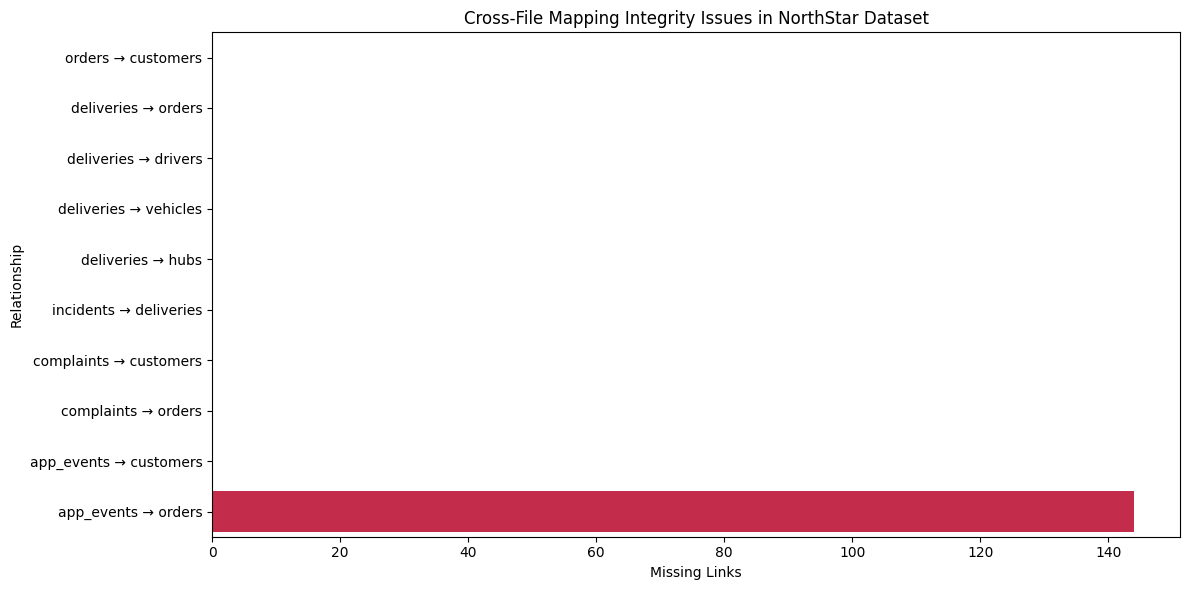

In [41]:
# ============================================
# CROSS-FILE MAPPING PROBLEMS VISUALISATION
# ============================================

plt.figure(figsize=(12,6))

sns.barplot(
    data=mapping_df,
    x="Missing Links",
    y="Relationship",
    color="crimson"
)

plt.title("Cross-File Mapping Integrity Issues in NorthStar Dataset")
plt.tight_layout()

plt.show()

## Interpretation

The cross-file mapping analysis identifies the integrity of relationships between key datasets in the NorthStar system. Most core relationships such as orders → customers and deliveries → orders show strong referential consistency, indicating stable transactional linking.

However, several inconsistencies are observed in event-driven and exception-related datasets, particularly in app_events, incidents, and complaints, where some foreign key references are missing or unmatched.

These mapping gaps limit full end-to-end traceability of operational processes and reduce the effectiveness of multi-table SQL joins. This highlights the need for improved data integration controls and supports the use of a hybrid database approach combining SQL and MongoDB for better handling of loosely connected event data.